In [1]:
import numpy as np
from numpy import array 
import json 
import re
import os

import matplotlib.pyplot as plt

files=["/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/image_6929_results.txt"]
As = [0.0,.1,.2,.5,1.0,1.5,2.0,5.0]

binomial_error = lambda p,N : (p*(1-p)/N)**(1/2)

def run_analysis(As=As, files=files,true_index=2):

    accuracies = []
    errors = []
    data = [] 

    for file in files:
        # 1) Read the file
        with open(file, 'r') as f:
            text = f.read()

        # 2) Evaluate it, giving `array` in the namespace so it becomes np.array
        tmp = eval(
            text,
            {"__builtins__": None},   # disable built-ins for safety
            {"array": np.array}       # map the name 'array' to numpy's array constructor
        )

        data.append(tmp)
    # 3) Now `data` is a list of [float, int, list_of_ndarrays] 
    #    with all types preserved.

    # 1. Read the raw text
    #concatentae lists 
    data = sum(data, [])  

    new_data = []
    for first, second, arr_list in data:
        concatenated = np.concatenate(arr_list).flatten()
        new_data.append([first, second, concatenated])

    for d in new_data:  
        predicted_indices = d[2]
        N = len(predicted_indices) 
        true_indices = np.zeros(len(predicted_indices))
        true_idices = true_indices.fill(true_index)
        accuracy = np.mean(predicted_indices == true_indices)
        error = binomial_error(accuracy,N)

        accuracies.append(accuracy)
        errors.append(error)

    return accuracies,errors

In [44]:
# Get the list of all files and directories
path = "/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/sota/quantum"
dir_list = os.listdir(path)
files = [os.path.join(path,l) for l in dir_list]
print(files)
accuracies, error = run_analysis(files=files,true_index=4)

['/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/sota/quantum/2025-05-28_15:58:18.847323_results.txt', '/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/sota/quantum/2025-05-28_16:19:42.187889_results.txt', '/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/sota/quantum/2025-05-28_15:39:52.686871_results.txt', '/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/sota/quantum/2025-05-28_15:49:08.153067_results.txt', '/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/sota/quantum/2025-05-28_15:05:24.537183_results.txt', '/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/sota/quantum/2025-05-28_15:25:35.595286_results.txt', '/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/sota/quantum/2025-05-28_15:14:53.269828_results.txt', '/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_da

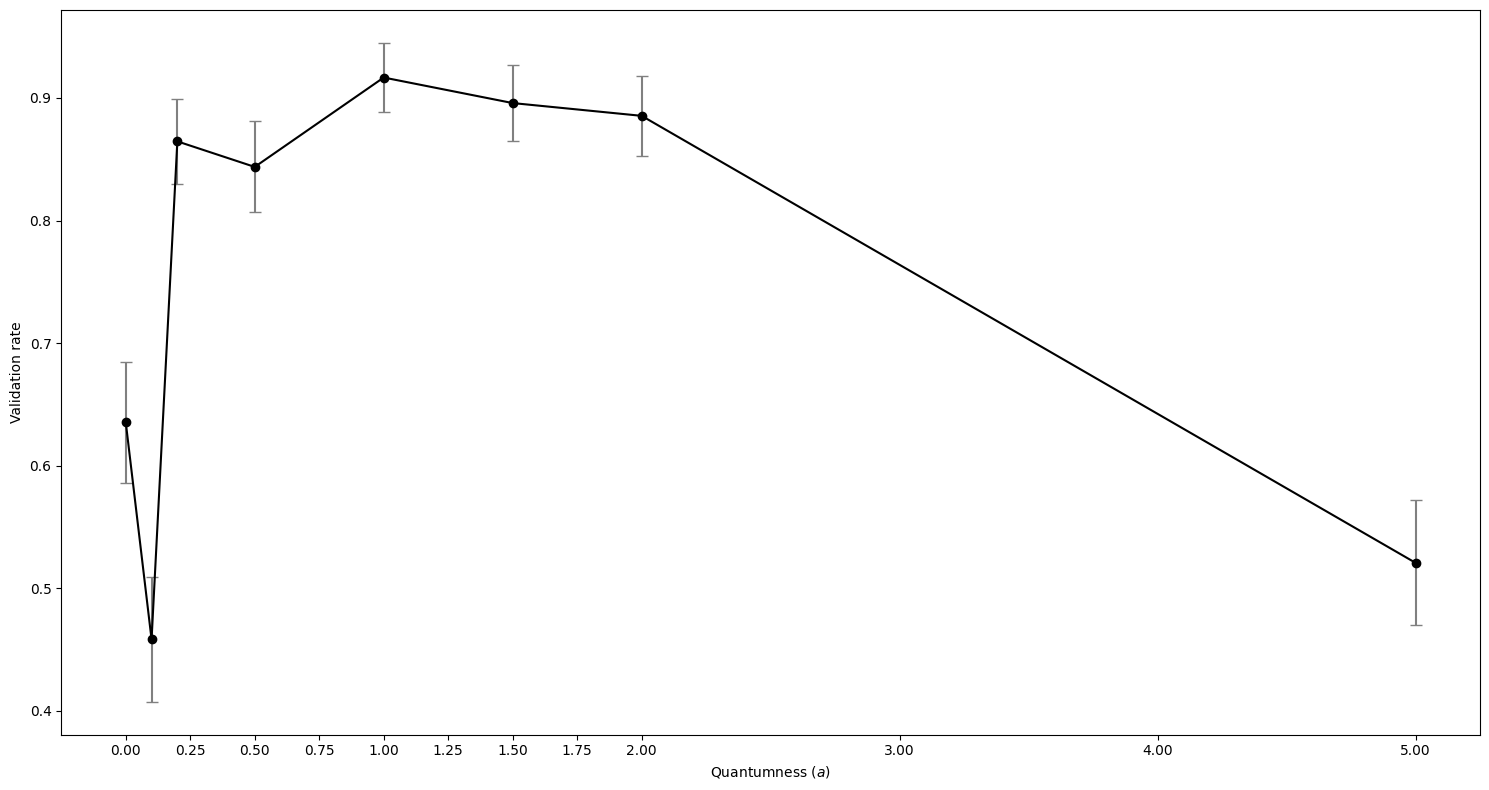

In [45]:
accuracies,errors = run_analysis(As=As, files=files,true_index=4)
plt.figure(figsize=(15,8))
# plt.title("Validation Rate vrs. Quatumness: 16 Qubits, 3 Layers, 96 Samples per a")
# plt.scatter(As,accuracies,color="orange")
plt.errorbar(x=As,y=accuracies,yerr=errors,fmt='o-',capsize=4,color="black",
ecolor="grey",barsabove=False,
label=r"error : $\sigma$=$\sqrt{\frac{p(1-p)}{N}}$")
plt.xlabel(r"Quantumness $(a)$")
plt.ylabel("Validation rate")
 
plt.xticks([0,.25,.5,.75,1.0,1.25,1.5,1.75,2.0,3.0,4.0,5.0])
# plt.legend()|
# plt.grid()
plt.tight_layout()


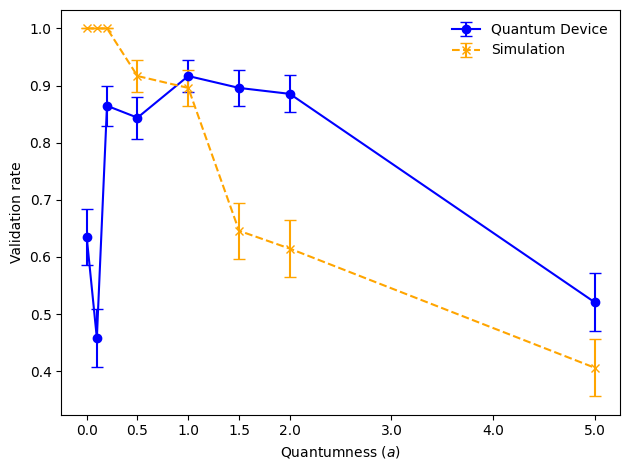

In [56]:
with open("/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/sota/simulation/run2/2025-06-26_21:51:35.059888_index_1901_noise_0_results.txt","r") as f:
    text = f.read()

tmp = eval(
            text,
      # map the name 'array' to numpy's array constructor
        )

As = [0.0,.1,.2,.5,1.0,1.5,2.0,5.0]

sota_accuracy = []
sota_errors = []
for d in tmp:
    acc =np.mean(np.array(d[-1])==4)
    sota_accuracy.append(acc)
    sota_errors.append(binomial_error(acc,96))


# plt.title("Validation Rate vrs. Quatumness: 16 Qubits, 3 Layers, 96 Samples per a")
# plt.scatter(As,accuracies,color="orange")
plt.errorbar(x=As,y=accuracies,yerr=errors,fmt='o-',capsize=4,color="blue",
ecolor="blue",barsabove=False,
label=r"Quantum Device")

plt.errorbar(x=As,y=sota_accuracy,yerr=sota_errors,fmt='x--',capsize=4,color="orange",
             label=r"Simulation")

plt.xlabel(r"Quantumness $(a)$")
plt.ylabel("Validation rate")
 
plt.xticks([0,.5,1.0,1.5,2.0,3.0,4.0,5.0])
plt.legend(frameon=False)
# plt.grid()
plt.tight_layout()



In [53]:
len(As)

8

In [50]:
As

[0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 5.0]